In [1]:
import pandas as pd
from commute_analysis import synthetic_population
base_dir = "/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis"

In [ ]:
# download the population grid data, save it to raw/data and load it into a pandas dataframe
df = synthetic_population.download_population_grid()
print(df.head())

In [2]:
# read the population_grid.csv file from deutschlandticket-commute-analysis/data/raw/population_grid.csv and load it into a pandas dataframe
from pathlib import Path
import geopandas as gpd

base_dir = "/home/msing/proj/jjdatascience/deutschlandticket-commute-analysis"
df = pd.read_csv(Path(base_dir) / "data" / "raw" / "population_grid.csv")

# transform this dataframe into a geopandas dataframe with a geometry column that contains the centroid of the grid cell
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["x_mp_100m"], df["y_mp_100m"]),
    crs="EPSG:3035",
)

gdf.head()

,GITTER_ID_100m,x_mp_100m,y_mp_100m,Einwohner,geometry
0,CRS3035RES100mN2689100E4337000,4337050,2689150,4,POINT (4337050 2689150)
1,CRS3035RES100mN2689100E4341100,4341150,2689150,11,POINT (4341150 2689150)
2,CRS3035RES100mN2690800E4341200,4341250,2690850,4,POINT (4341250 2690850)
3,CRS3035RES100mN2691200E4341200,4341250,2691250,12,POINT (4341250 2691250)
4,CRS3035RES100mN2691300E4341200,4341250,2691350,3,POINT (4341250 2691350)


In [23]:
# create a geopandas.GeoDataFrame target_area that filters a circular area of 30 km radius around the center point (53.686439, 10.046120)
import geopandas as gpd
from shapely.geometry import Point

def create_target_area(center_lat, center_lon, radius_km):
    center = Point(center_lon, center_lat)

    target_area = gpd.GeoDataFrame(
        geometry=[center],
        crs="EPSG:4326",
    )

    # Accurate metric projection for Hamburg / northern Germany
    target_area = target_area.to_crs("EPSG:25832")

    target_area["geometry"] = target_area.geometry.buffer(
        radius_km * 1000
    )

    return target_area

center_lat = 53.686439
center_lon = 10.046120
radius_km = 50

target_area = create_target_area(center_lat, center_lon, radius_km)

In [28]:
# create random employee sample of 1000 employees with random home locations within the target area
import numpy as np
gaussian_scale=20_000
samples = synthetic_population.sample_population_weighted_locations(gdf, "Einwohner", 1000, target_area=target_area, filter_mode="gaussian", gaussian_scale=gaussian_scale)

In [29]:
import matplotlib.pyplot as plt
import contextily as cx

In [30]:
from matplotlib.axes import Axes

def plot_sampling_probability_map(
    probability_grid: gpd.GeoDataFrame,
    target_area: gpd.GeoDataFrame | None = None,
    center_point: gpd.GeoDataFrame | None = None,
    samples: gpd.GeoDataFrame | None = None,
    ax: Axes | None = None,
    title: str = "Synthetic employee sampling probability",
    cmap: str = "viridis",
    show_legend: bool = True,
) -> Axes:
    """
    Plot the sampling probability assigned to each grid cell.

    Parameters
    ----------
    probability_grid : geopandas.GeoDataFrame
        Grid returned by calculate_sampling_probability_grid().
    target_area : geopandas.GeoDataFrame, optional
        Boundary to draw around the sampling region.
    center_point : geopandas.GeoDataFrame, optional
        Workplace or Gaussian center point.
    samples : geopandas.GeoDataFrame, optional
        Generated sample points to overlay.
    ax : matplotlib.axes.Axes, optional
        Existing Matplotlib axis.
    title : str
        Plot title.
    cmap : str
        Matplotlib colour map.
    show_legend : bool
        Whether to show the probability legend.

    Returns
    -------
    matplotlib.axes.Axes
        The axis containing the plot.
    """
    if "sampling_probability" not in probability_grid.columns:
        raise KeyError(
            "probability_grid must contain "
            "'sampling_probability'."
        )

    if probability_grid.crs is None:
        raise ValueError(
            "probability_grid must have a CRS."
        )

    if ax is None:
        _, ax = plt.subplots(figsize=(10, 10))

    probability_grid.plot(
        ax=ax,
        column="sampling_probability",
        cmap=cmap,
        legend=show_legend,
        linewidth=0,
        legend_kwds={
            "label": "Probability of selecting grid cell",
            "shrink": 0.7,
        },
    )

    if target_area is not None:
        target_area.to_crs(
            probability_grid.crs
        ).boundary.plot(
            ax=ax,
            linewidth=1.5,
            label="Target area",
        )

    if samples is not None:
        samples.to_crs(
            probability_grid.crs
        ).plot(
            ax=ax,
            markersize=12,
            marker="o",
            facecolor="none",
            edgecolor="white",
            linewidth=0.7,
            label="Sampled employees",
        )

    if center_point is not None:
        center_point.to_crs(
            probability_grid.crs
        ).plot(
            ax=ax,
            marker="*",
            markersize=180,
            color="red",
            edgecolor="white",
            linewidth=0.8,
            label="Workplace",
            zorder=5,
        )

    ax.set_title(title)
    ax.set_axis_off()

    if any(
        item is not None
        for item in [target_area, samples, center_point]
    ):
        ax.legend()

    return ax

  employee_id  source_population  source_probability  distance_weight  \
0   EMP-00001              139.0            0.000015         0.221829   
1   EMP-00002              161.0            0.000062         0.780735   
2   EMP-00003               23.0            0.000003         0.293025   
3   EMP-00004               56.0            0.000007         0.238349   
4   EMP-00005              126.0            0.000027         0.424802   

                  geometry  
0  POINT (4352750 3378150)  
1  POINT (4322750 3383650)  
2  POINT (4334650 3427150)  
3  POINT (4340350 3427350)  
4  POINT (4312350 3374250)  
       sampling_probability  cell_area_km2  probability_density_km2
count          1.089280e+05   1.089280e+05            108928.000000
mean           9.180376e-06   1.000000e-06                 9.180376
std            1.728421e-05   4.235184e-22                17.284209
min            6.537746e-08   1.000000e-06                 0.065377
25%            8.273272e-07   1.000000e-06     

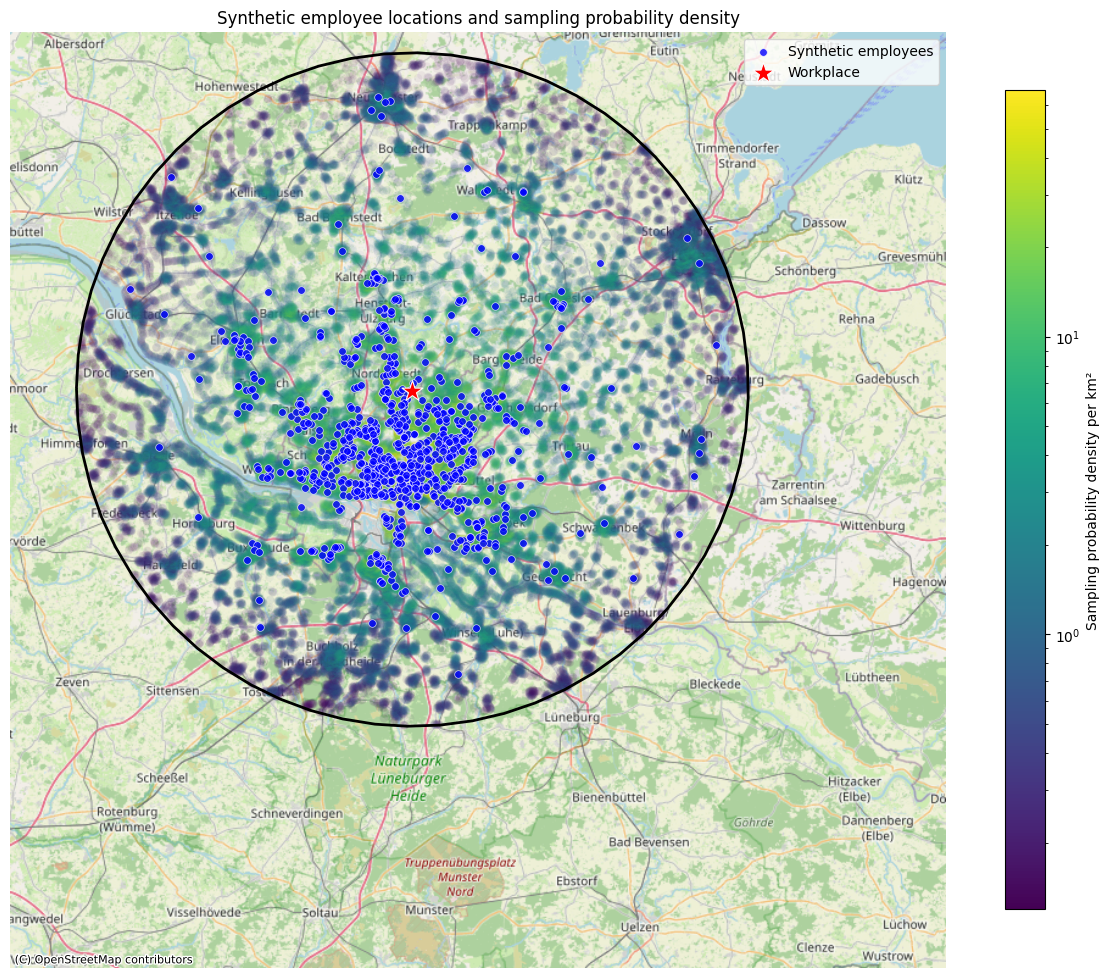

In [31]:
print(samples.head())
# create a map visualization of the points in the samples geodataframe and the probability density using geopandas and matplotlib

from matplotlib.colors import LogNorm

# ------------------------------------------------------------
# 1. Calculate sampling probabilities
# ------------------------------------------------------------

probability_grid = (
    synthetic_population.calculate_sampling_probability_grid(
        population_grid=gdf,
        population_column="Einwohner",
        target_area=target_area,
        filter_mode="gaussian",
        gaussian_scale=gaussian_scale,
    )
    .copy()
)


# ------------------------------------------------------------
# 2. Calculate density in a metre-based CRS
# ------------------------------------------------------------

# EPSG:3035 is particularly suitable for European area calculations.
probability_projected = probability_grid.to_crs("EPSG:3035")

probability_projected["cell_area_km2"] = (
    1 / 1_000_000
)

probability_projected["probability_density_km2"] = (
    probability_projected["sampling_probability"]
    / probability_projected["cell_area_km2"]
)

# Remove invalid values
probability_projected["probability_density_km2"] = (
    probability_projected["probability_density_km2"]
    .replace([np.inf, -np.inf], np.nan)
)

probability_projected = probability_projected.dropna(
    subset=["probability_density_km2"]
)


# ------------------------------------------------------------
# 3. Inspect the values
# ------------------------------------------------------------

print(
    probability_projected[
        [
            "sampling_probability",
            "cell_area_km2",
            "probability_density_km2",
        ]
    ].describe()
)

print(
    "Positive-density cells:",
    (probability_projected["probability_density_km2"] > 0).sum(),
)


# ------------------------------------------------------------
# 4. Convert plotting layers to Web Mercator
# ------------------------------------------------------------

probability_web = probability_projected.to_crs("EPSG:3857")
samples_web = samples.to_crs("EPSG:3857")
area_web = target_area.to_crs("EPSG:3857")

center_point = gpd.GeoDataFrame(
    {"name": ["Workplace"]},
    geometry=[Point(center_lon, center_lat)],
    crs="EPSG:4326",
).to_crs("EPSG:3857")


# Only positive values can be displayed with LogNorm
density_to_plot = probability_web[
    probability_web["probability_density_km2"] > 0
].copy()

density_values = density_to_plot["probability_density_km2"]

# Ignore extreme outliers when setting the displayed colour range
vmin = density_values.quantile(0.02)
vmax = density_values.quantile(0.98)

if vmin <= 0 or vmin == vmax:
    norm = None
else:
    norm = LogNorm(vmin=vmin, vmax=vmax)


# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 12))


# Set map extent before adding the basemap
min_x, min_y, max_x, max_y = area_web.total_bounds
padding = 2_000

ax.set_xlim(min_x - padding, max_x + padding)
ax.set_ylim(min_y - padding, max_y + padding)


# Add basemap first
cx.add_basemap(
    ax,
    source=cx.providers.OpenStreetMap.Mapnik,
    crs=probability_web.crs,
    reset_extent=False,
    zorder=0,
)


# Probability-density grid
density_to_plot.plot(
    ax=ax,
    column="probability_density_km2",
    cmap="viridis",
    norm=norm,
    alpha=0.05,
    edgecolor="none",
    legend=True,
    zorder=1,
    legend_kwds={
        "label": "Sampling probability density per km²",
        "shrink": 0.7,
    },
)


# Target-area boundary
area_web.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2,
    zorder=2,
)


# Employee samples
samples_web.plot(
    ax=ax,
    marker="o",
    color="blue",
    edgecolor="white",
    linewidth=0.5,
    markersize=30,
    alpha=0.8,
    zorder=3,
    label="Synthetic employees",
)


# Workplace
center_point.plot(
    ax=ax,
    color="red",
    edgecolor="white",
    linewidth=0.8,
    marker="*",
    markersize=250,
    zorder=4,
    label="Workplace",
)


ax.set_title(
    "Synthetic employee locations and sampling probability density"
)

ax.legend(loc="upper right")
ax.set_axis_off()

plt.tight_layout()
plt.show()